In [13]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential

from keras.layers import Dense, Input

from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten



In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import matplotlib.pyplot as plt
train_dir = '/content/drive/MyDrive/Colab Notebooks/Food'

In [12]:
img_width, img_height = 128,128
batch_size = 32
train_datagen = ImageDataGenerator(rescale = 1./255, rotation_range = 30, width_shift_range=0.2, height_shift_range= 0.2,
                                   shear_range = 0.2 , zoom_range = 0.2 , horizontal_flip = True,
                                   fill_mode = 'constant', cval=0.0)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_width,img_height),
                                                    batch_size = batch_size , class_mode = 'categorical')

Found 754 images belonging to 5 classes.


In [17]:
model = Sequential([
 Conv2D(32, (3, 3), input_shape=(img_width, img_height, 3), activation='relu'),
 MaxPooling2D(pool_size=(2, 2)),
 Conv2D(64, (3, 3), activation='relu'),
 MaxPooling2D((2,2)),
 Conv2D(128, (3, 3), activation='relu'),
 MaxPooling2D((2,2)),

 Flatten(),
 Dense(128, activation = 'relu'),
 Dropout(0.5),
 Dense(5, activation = 'softmax')
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,308,510 (12.62 MB)

 Trainable params: 3,308,510 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 224s 9s/step - accuracy: 0.3422 - loss: 1.4936
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 729ms/step - accuracy: 0.3939 - loss: 1.3549
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 710ms/step - accuracy: 0.4363 - loss: 1.3375
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 747ms/step - accuracy: 0.5477 - loss: 1.1662
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 701ms/step - accuracy: 0.5756 - loss: 1.1279
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 705ms/step - accuracy: 0.6446 - loss: 1.0181
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 751ms/step - accuracy: 0.6154 - loss: 1.0349
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 711ms/step - accuracy: 0.6578 - loss: 0.9771
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 740ms/step - accuracy: 0.6910 - loss: 0.8876
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 714ms/step - accuracy: 0.7029 - loss: 0.8506
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 721ms/step - accuracy: 0.6830 - loss: 0.8648
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 

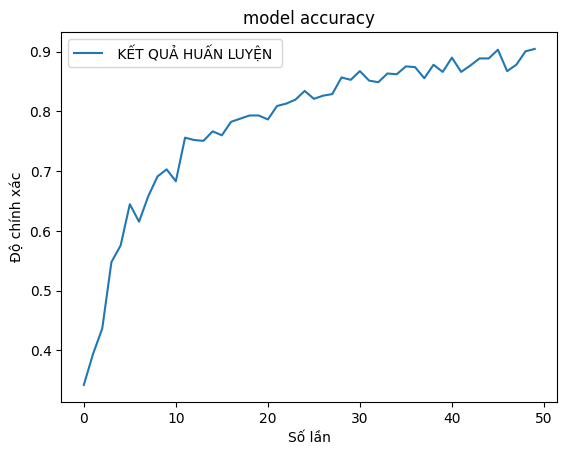

In [18]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(train_generator,epochs = 50)
plt.plot(history.history['accuracy'], label = ' KẾT QUẢ HUẤN LUYỆN ')
plt.title('model accuracy')
plt.ylabel('Độ chính xác')
plt.xlabel('Số lần')
plt.legend()
plt.show()

In [26]:
model = tf.keras.models.load_model('/content/drive/MyDrive/food_model.keras')

In [21]:
from keras.utils import load_img
import numpy as np
path = ['banhchung.jpg']
for i in path :
  img = load_img(i, target_size=(img_width, img_height))
  plt.imshow(img)
  plt.show()

  # Preprocess the image for prediction
  img_array = np.array(img) # Convert to numpy array
  img_array = img_array / 255.0 # Normalize pixel values
  img_array = img_array.reshape(1, img_width, img_height, 3) # Reshape for model input

  # Make prediction
  predictions = model.predict(img_array)
  predicted_class_index = np.argmax(predictions)
  confidence = np.max(predictions)

  # Get class label
  class_label = {v:k for k , v in train_generator.class_indices.items()}
  predicted_food_name = class_label[predicted_class_index]

  # Print results
  print("Món ăn:", predicted_food_name)
  print("Độ tự tin:", confidence * 100, "%")

FileNotFoundError: [Errno 2] No such file or directory: 'banhchung.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


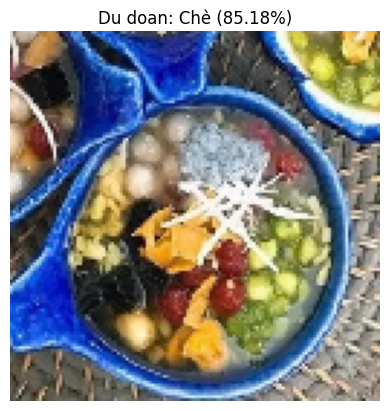

Kết quả nhận diện món ăn: Chè
Độ tự tin (Confidence): 85.18%


In [29]:
from keras.models import load_model

from keras.utils import load_img, img_to_array

import numpy as np

import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/food_model.keras'

image_path = '/content/che.jpg'

reloaded_model = load_model (model_path)

img_width, img_height = 128, 128

img = load_img(image_path, target_size=(img_width, img_height), color_mode='rgb')

img_array = img_to_array(img)

img_array = np.expand_dims (img_array, axis=0)

img_array /= 255.0

predictions = reloaded_model.predict(img_array)

predicted_class_idx = np.argmax(predictions, axis=1) [0]

confidence = np.max(predictions) * 100

labels_map = {v: k for k, v in train_generator.class_indices.items()}

predicted_class_name = labels_map[predicted_class_idx]

plt.imshow(img)

plt.title(f"Du doan: {predicted_class_name} ({confidence:.2f}%)")

plt.axis('off')

plt.show()

print(f"Kết quả nhận diện món ăn: {predicted_class_name}")

print(f"Độ tự tin (Confidence): {confidence:.2f}%")